In [1]:
import sys
sys.path.append("src")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quantum_algorithms as qa

In [2]:
# Common settings

shots = 1024
n_values = [1, 3, 5, 7, 9]
theta_values= np.radians(np.arange(0, 181, 10))

f_const = qa.deutsch_jozsa.f_constant_1
f_bal = qa.deutsch_jozsa.f_balanced_parity

axes = {
    "X": (1, 0, 0),
    "Y": (0, 1, 0),
    "Z": (0, 0, 1),
}

error_positions = {
    "E1_before_H": qa.deutsch_jozsa.deutsch_jozsa_error1,
    "E2_after_first_H": qa.deutsch_jozsa.deutsch_jozsa_error2,
    "E3_after_oracle": qa.deutsch_jozsa.deutsch_jozsa_error3,
    "E4_after_final_H": qa.deutsch_jozsa.deutsch_jozsa_error4,
}

label_map = {
    "no_error": "No Error",
    "E1_before_H": r"$\mathcal{E}_1$ before first $H$",
    "E2_after_first_H": r"$\mathcal{E}_2$ after first $H$",
    "E3_after_oracle": r"$\mathcal{E}_3$ after oracle",
    "E4_after_final_H": r"$\mathcal{E}_4$ after final $H$",
}

def get_success_probability(function_name, P0):
    if function_name in ["constant_0", "constant_1"]:
        return P0
    if function_name == "balanced_parity":
        return 1 - P0
    raise ValueError(f"Unknown function: {function_name}")

def standard_error(p, shots):
    return np.sqrt(p * (1 - p) / shots)

In [3]:
# Full Experiment

start_time = time.time()
rng = np.random.default_rng(12345)
results = []

for n in n_values:
    print(f"Running n = {n}")

    for theta in theta_values:
        theta_deg = np.degrees(theta)

        for axis_name, axis in axes.items():
            for target_qubit in range(n):

                state_const_ref = qa.deutsch_jozsa.deutsch_jozsa(n, f_const)
                state_bal_ref = qa.deutsch_jozsa.deutsch_jozsa(n, f_bal)

                samples_const_ref = qa.deutsch_jozsa.sample_measurements_input(
                    state_const_ref, n, shots, rng
                )
                samples_bal_ref = qa.deutsch_jozsa.sample_measurements_input(
                    state_bal_ref, n, shots, rng
                )

                P0_constant_ref = samples_const_ref[0] / shots
                P0_balanced_ref = samples_bal_ref[0] / shots

                results.append({
                    "n": n,
                    "theta_rad": theta,
                    "theta_deg": theta_deg,
                    "axis": axis_name,
                    "target_qubit": target_qubit,
                    "error_position": "no_error",
                    "P0_constant": P0_constant_ref,
                    "P0_balanced": P0_balanced_ref,
                    "success_constant": P0_constant_ref,
                    "success_balanced": 1 - P0_balanced_ref,
                    "average_success": (P0_constant_ref + (1 - P0_balanced_ref)) / 2,
                    "shots": shots,
                })

                for error_name, error_function in error_positions.items():

                    state_const = error_function(
                        n, f_const, theta, target_qubit, axis
                    )

                    state_bal = error_function(
                        n, f_bal, theta, target_qubit, axis
                    )

                    samples_const = qa.deutsch_jozsa.sample_measurements_input(
                        state_const, n, shots, rng
                    )
                    samples_bal = qa.deutsch_jozsa.sample_measurements_input(
                        state_bal, n, shots, rng
                    )

                    P0_constant = samples_const[0] / shots
                    P0_balanced = samples_bal[0] / shots

                    results.append({
                        "n": n,
                        "theta_rad": theta,
                        "theta_deg": theta_deg,
                        "axis": axis_name,
                        "target_qubit": target_qubit,
                        "error_position": error_name,
                        "P0_constant": P0_constant,
                        "P0_balanced": P0_balanced,
                        "success_constant": P0_constant,
                        "success_balanced": 1 - P0_balanced,
                        "average_success": (P0_constant + (1 - P0_balanced)) / 2,
                        "shots": shots,
                    })

end_time = time.time()

df = pd.DataFrame(results)

print("Experiment complete.")
print("Dataset shape:", df.shape)
print(f"Runtime: {(end_time - start_time) / 3600:.2f} hours")

df.head()

Running n = 1
Running n = 3
Running n = 5
Running n = 7
Running n = 9
Experiment complete.
Dataset shape: (7125, 12)
Runtime: 0.69 hours


,n,theta_rad,theta_deg,axis,target_qubit,error_position,P0_constant,P0_balanced,success_constant,success_balanced,average_success,shots
0,1,0.0,0.0,X,0,no_error,1.0,0.0,1.0,1.0,1.0,1024
1,1,0.0,0.0,X,0,E1_before_H,1.0,0.0,1.0,1.0,1.0,1024
2,1,0.0,0.0,X,0,E2_after_first_H,1.0,0.0,1.0,1.0,1.0,1024
3,1,0.0,0.0,X,0,E3_after_oracle,1.0,0.0,1.0,1.0,1.0,1024
4,1,0.0,0.0,X,0,E4_after_final_H,1.0,0.0,1.0,1.0,1.0,1024


In [4]:
# Save Dataset

csv_name = "dja_full_master_intership_results_shots_1024.csv"
df.to_csv(csv_name, index=False)

print(f"Results saved as: {csv_name}")

Results saved as: dja_full_master_intership_results_shots_1024.csv


In [5]:
# Line Plot: Error Position Comparison

def plot_average_success(df, n_plot, axis_plot, target_plot):

    plot_df = df[
        (df["n"] == n_plot) &
        (df["axis"] == axis_plot) &
        (df["target_qubit"] == target_plot)
    ]

    plt.figure(figsize=(10, 6))

    for error_pos in [
        "no_error",
        "E1_before_H",
        "E2_after_first_H",
        "E3_after_oracle",
        "E4_after_final_H",
    ]:
        subset = plot_df[plot_df["error_position"] == error_pos]

        plt.plot(
            subset["theta_deg"],
            subset["average_success"],
            linewidth=2,
            label=label_map[error_pos]
        )

    plt.xlabel(r"Rotation angle $\theta$ (degrees)", fontsize=12)
    plt.ylabel("Average success probability", fontsize=12)

    plt.title(
        f"Deutsch–Jozsa Algorithm under Rotation Errors\n"
        f"n={n_plot}, axis={axis_plot}, target qubit={target_plot}, shots={shots}",
        fontsize=13
    )

    plt.xlim(0, 180)
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Error position")
    plt.tight_layout()

    filename = f"lineplot_n{n_plot}_{axis_plot}_q{target_plot}.pdf"
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Saved figure: {filename}")

In [6]:
# Scalability Plot

def plot_scalability(df, theta_choice=90, axis_choice="X", error_choice="E4_after_final_H"):

    scale_df = df[
        (df["theta_deg"] == theta_choice) &
        (df["axis"] == axis_choice) &
        (df["error_position"] == error_choice)
    ]

    grouped = scale_df.groupby("n")["average_success"].mean()

    plt.figure(figsize=(8, 5))

    plt.plot(
        grouped.index,
        grouped.values,
        marker="o",
        linewidth=2
    )

    plt.xlabel("Number of input qubits n")
    plt.ylabel("Average success probability")
    plt.title(
        f"Scalability under {label_map[error_choice]} noise\n"
        f"axis={axis_choice}, θ={theta_choice}°, shots={shots}"
    )

    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    filename = f"scalability_{error_choice}_{axis_choice}_{theta_choice}deg.pdf"
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Saved figure: {filename}")

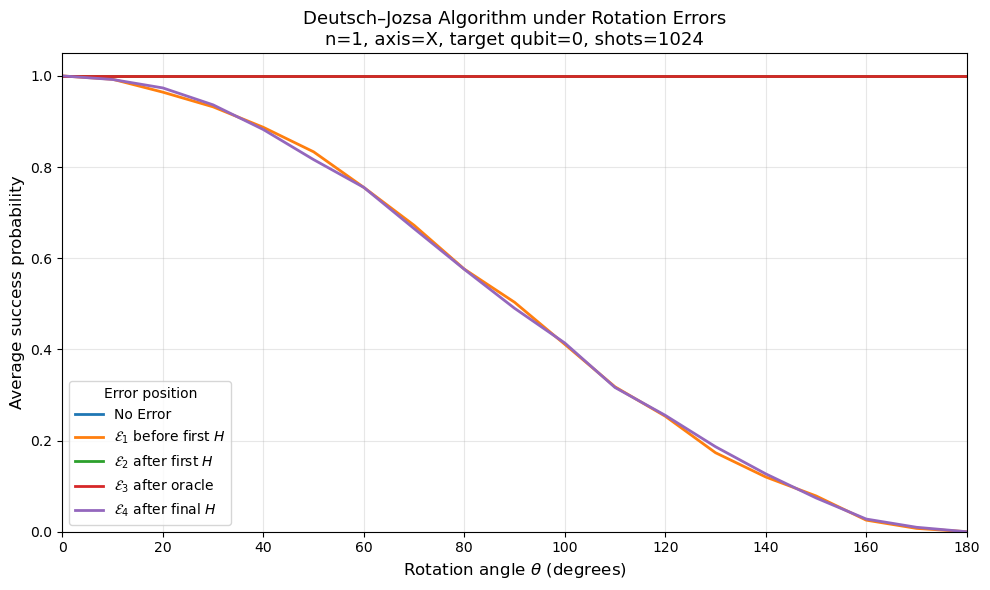

Saved figure: lineplot_n1_X_q0.pdf


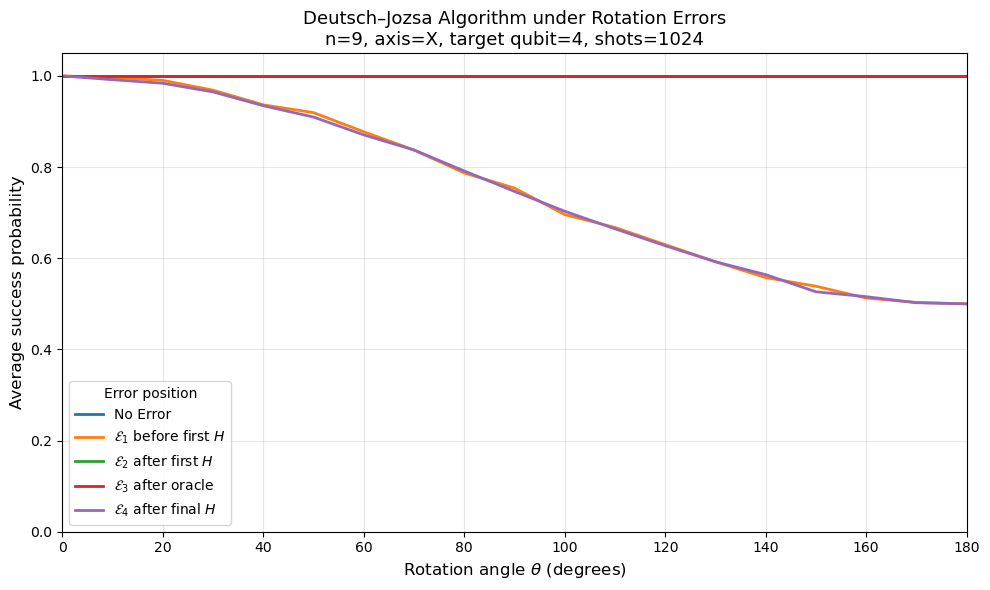

Saved figure: lineplot_n9_X_q4.pdf


In [7]:
plot_average_success(df, n_plot=1, axis_plot="X", target_plot=0)
plot_average_success(df, n_plot=9, axis_plot="X", target_plot=4) 

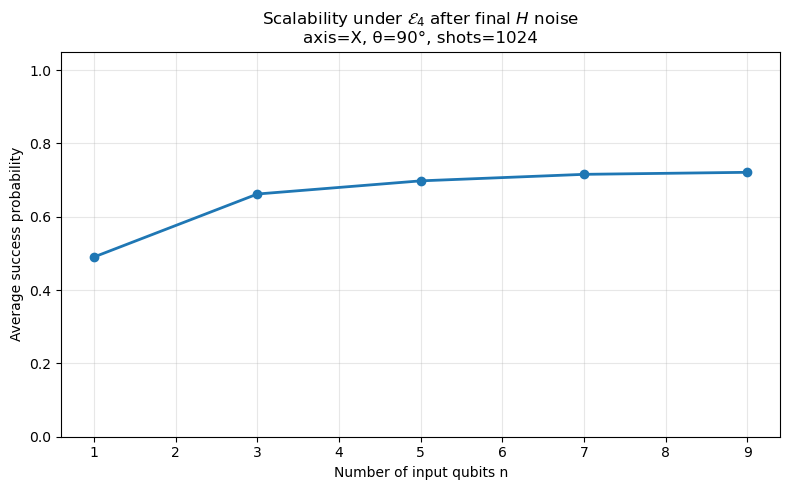

Saved figure: scalability_E4_after_final_H_X_90deg.pdf


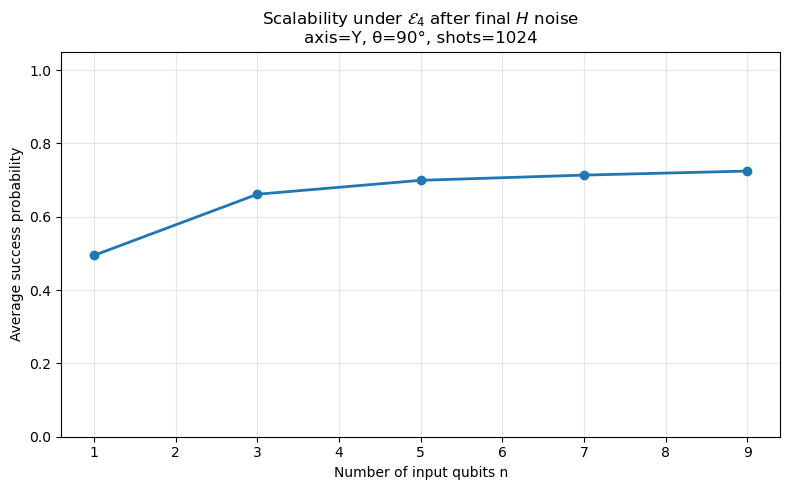

Saved figure: scalability_E4_after_final_H_Y_90deg.pdf


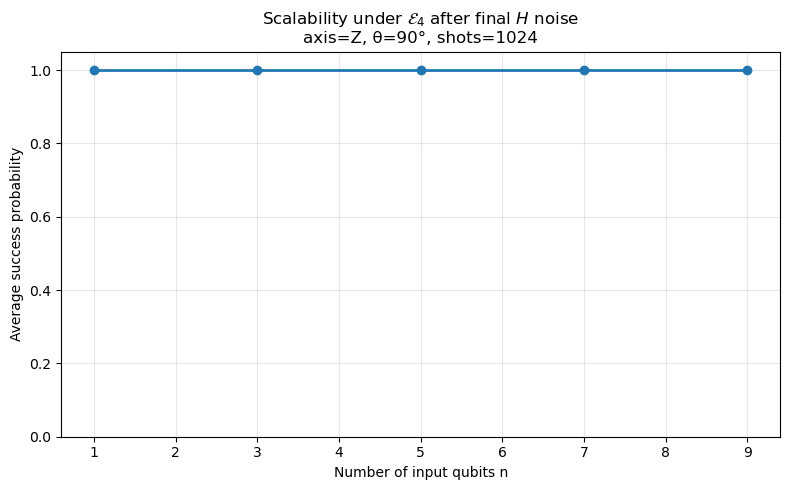

Saved figure: scalability_E4_after_final_H_Z_90deg.pdf


In [8]:
plot_scalability(df, theta_choice=90, axis_choice="X", error_choice="E4_after_final_H") 
plot_scalability(df, theta_choice=90, axis_choice="Y", error_choice="E4_after_final_H") 
plot_scalability(df, theta_choice=90, axis_choice="Z", error_choice="E4_after_final_H") 

In [ ]:
plot_scalability(df, theta_choice=90, axis_choice="X", error_choice="E2_after_first_H")
plot_scalability(df, theta_choice=90, axis_choice="Y", error_choice="E2_after_first_H")
plot_scalability(df, theta_choice=90, axis_choice="Z", error_choice="E2_after_first_H")